Creating DataSet Demo

In [1]:
import pandas as pd 
import numpy as np 
 
# Reproducibility 
rng = np.random.default_rng(42) 
 
n = 1000 # rowsSize
df = pd.DataFrame({ 
    "age": rng.integers(18, 70, size=n), 
    "usage_gb": np.round(rng.normal(12, 6, size=n).clip(0, None), 1), 
    "complaints": rng.integers(0, 6, size=n), 
    "tenure_months": rng.integers(1, 60, size=n), 
    "plan_type": rng.choice(["Prepaid", "Postpaid"], size=n, p=[0.6, 0.4]) 
}) 

In [4]:
# Simple churn signal (not perfect): high complaints + low tenure + low usage more likely to churn 
logit = ( 
    -2.0 
    + 0.35*df["complaints"] 
    - 0.03*df["tenure_months"] 
    - 0.04*df["usage_gb"] 
    + (df["plan_type"] == "Prepaid").astype(int)*0.4 
) 
prob = 1/(1+np.exp(-logit)) 
df["churn"] = (rng.random(n) < prob).astype(int) 
 
# Intentionally add a few missing/odd values to practice fixing (no row drops) 
df.loc[rng.choice(df.index, 5, replace=False), "usage_gb"] = np.nan 
df.loc[rng.choice(df.index, 3, replace=False), "age"] = np.nan 
df.loc[rng.choice(df.index, 3, replace=False), "plan_type"] = None 
 
df.to_csv("churn_data.csv", index=False) 
print("Saved churn_data.csv with shape:", df.shape) 
df.head()
 
# Your data is ready 
 


Saved churn_data.csv with shape: (1000, 6)


,age,usage_gb,complaints,tenure_months,plan_type,churn
0,22.0,20.6,1,45,Prepaid,0
1,58.0,12.5,3,7,Prepaid,0
2,52.0,15.5,1,25,Postpaid,0
3,40.0,11.7,5,1,Postpaid,0
4,40.0,11.0,4,27,Prepaid,0


In [5]:
# 3) Load & fix the data (no dropping) – ETL 
 
import pandas as pd 
from sklearn.impute import SimpleImputer 
 
df = pd.read_csv("churn_data.csv") 
print("Original shape:", df.shape) 
display(df.head()) 
 
# --- Numeric imputation: fill NaNs with median (robust to outliers) --- 
num_cols = ["age", "usage_gb", "complaints", "tenure_months"] 
num_imputer = SimpleImputer(strategy="median") 
df[num_cols] = num_imputer.fit_transform(df[num_cols]) 
 
# --- Categorical imputation: fill missing with most frequent --- 
cat_cols = ["plan_type"] 
cat_imputer = SimpleImputer(strategy="most_frequent") 
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols]) 
 
# --- Encode plan_type to numeric (0=Prepaid, 1=Postpaid) --- 
df["plan_type_enc"] = (df["plan_type"] == "Postpaid").astype(int) 
 
# --- Feature matrix (X) and target (y) --- 
X = df[["age", "usage_gb", "complaints", "tenure_months", "plan_type_enc"]] 
y = df["churn"].astype(int) 
 
print("Any remaining NaNs? ->", X.isna().sum().sum(), y.isna().sum()) 
 
# ---    Save cleaned dataset to CSV --- 
df.to_csv("updated_churn_data.csv", index=False) 
print("   Saved cleaned dataset as 'updated_churn_data.csv' with", len(df), "rows.") 

Original shape: (1000, 6)


,age,usage_gb,complaints,tenure_months,plan_type,churn
0,22.0,20.6,1,45,Prepaid,0
1,58.0,12.5,3,7,Prepaid,0
2,52.0,15.5,1,25,Postpaid,0
3,40.0,11.7,5,1,Postpaid,0
4,40.0,11.0,4,27,Prepaid,0


Any remaining NaNs? -> 0 0
   Saved cleaned dataset as 'updated_churn_data.csv' with 1000 rows.


4) Train/Test split & model training 
# This will import functions from the scikit-learn (machine learning) library. Helps split your 
dataset into two parts: one for training the model and one for testing it. 
DecisionTreeClassifier is a machine learning algorithm that learns to make predictions by 
building a tree-like structure of decisions

In [ ]:
from sklearn.model_selection import train_test_split 

from sklearn.tree import DecisionTreeClassifier 
 
# Split 
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.3, stratify=y, random_state=42 
) 
 
# Train Decision Tree (simple baseline) 
clf = DecisionTreeClassifier(max_depth=5, random_state=42) 
clf.fit(X_train, y_train) 
 
# This is where the learning happens. The model looks at all the feature values in X_train 
# and the correct answers in y_train, and learns patterns that connect them. After this step, the 
# model can make predictions on unseen data. 
print("Model trained.")

# # Predictions
# y_pred = clf.predict(X_test)

# # Accuracy calculation
# accuracy = accuracy_score(y_test, y_pred)

# print("Decision trained.")
# print("Model Accuracy:", accuracy)

Model trained.
Decision trained.
Model Accuracy: 0.8333333333333334


5) Evaluate (accuracy + precision/recall/F1 + confusion matrix) 
 
This code helps you to check how well your trained Decision Tree model performed. It 
compares the model’s predictions with the real answers, prints accuracy and other metrics, 
and then shows a confusion matrix plot to visualize the results. 


Accuracy: 83.33%

Classification report:
              precision    recall  f1-score   support

           0      0.879     0.939     0.908       264
           1      0.111     0.056     0.074        36

    accuracy                          0.833       300
   macro avg      0.495     0.497     0.491       300
weighted avg      0.787     0.833     0.808       300

Confusion matrix:
 [[248  16]
 [ 34   2]]


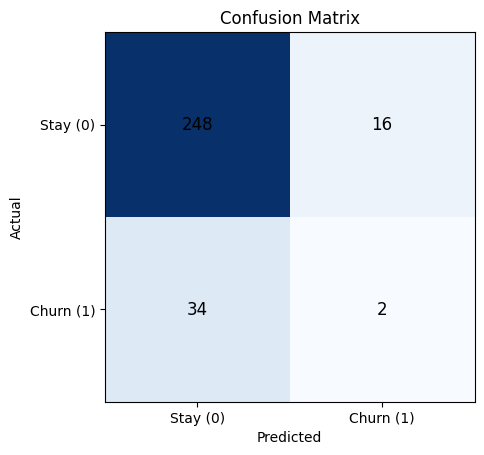

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix 
import matplotlib.pyplot as plt 
import numpy as np 
 
# Predict 
y_pred = clf.predict(X_test) 
 
# Accuracy 
acc = accuracy_score(y_test, y_pred) 
print(f"Accuracy: {acc:.2%}") 
 
# Detailed metrics 
print("\nClassification report:") 
print(classification_report(y_test, y_pred, digits=3)) 
 
# Confusion matrix 
cm = confusion_matrix(y_test, y_pred) 
print("Confusion matrix:\n", cm) 
 
# Top-left (50) -> correctly predicted “Stay” 
# Top-right (10) -> false alarms (predicted churn, actually stayed) 
# Bottom-right (35) -> correctly predicted “Churn” 
# Bottom-left (5) -> missed churns 
 
 
# Plot nicely 
fig, ax = plt.subplots() 
ax.imshow(cm, cmap="Blues") 
ax.set_title("Confusion Matrix") 
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual") 
for (i, j), v in np.ndenumerate(cm): 
    ax.text(j, i, str(v), ha='center', va='center', fontsize=12) 
ax.set_xticks([0,1]); ax.set_yticks([0,1]) 
ax.set_xticklabels(["Stay (0)", "Churn (1)"]); ax.set_yticklabels(["Stay (0)", "Churn (1)"]) 
plt.show() 
 
# CHECK Accuracy of Your MODEL 
 
# • Makes predictions using your trained model. 
# • Calculates how accurate those predictions are. 
# • Shows detailed metrics like precision, recall, and F1-score. 
# • Displays a confusion matrix — both as text and as a colored chart — to help you 
# visualize model performance. 
 
 


Random Forest

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train Random Forest with bootstrap sampling
rf_model = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=5,
    bootstrap=True,       # enables bootstrapping (Xboot concept)
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy calculation
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Model trained.")
print("Model Accuracy:", accuracy)

Random Forest Model trained.
Model Accuracy: 0.88


Accuracy: 88.00%

Classification report:
              precision    recall  f1-score   support

           0      0.880     1.000     0.936       264
           1      0.000     0.000     0.000        36

    accuracy                          0.880       300
   macro avg      0.440     0.500     0.468       300
weighted avg      0.774     0.880     0.824       300

Confusion matrix:
 [[264   0]
 [ 36   0]]


c:\Users\hp\.conda\envs\mlenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\.conda\envs\mlenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\.conda\envs\mlenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


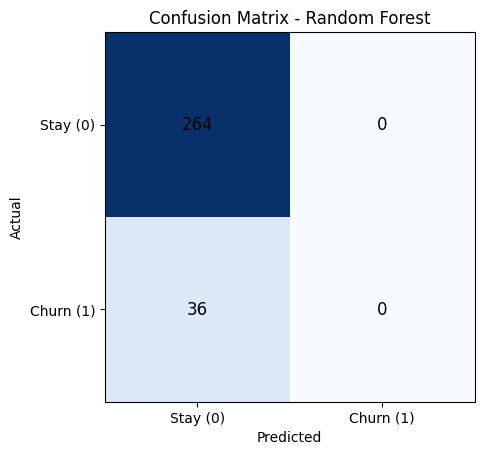

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    bootstrap=True,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

# Detailed metrics
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Example explanation
# Top-left -> correctly predicted “Stay”
# Top-right -> false alarms
# Bottom-right -> correctly predicted “Churn”
# Bottom-left -> missed churns

# Plot confusion matrix
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix - Random Forest")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center', fontsize=12)

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Stay (0)", "Churn (1)"])
ax.set_yticklabels(["Stay (0)", "Churn (1)"])

plt.show()